In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
print(df.shape)

df.info()

df.head()

(1200, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
print(df.isnull().sum())

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


In [5]:
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include="object").columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicate Rows: 0


In [7]:
encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col].astype(str))

In [8]:
df.drop(
    columns=[
        "OrderID",
        "CustomerID",
        "TrackingNumber"
    ],
    inplace=True
)

In [10]:
print(df.dtypes)

Date               datetime64[us]
Product                     int64
Quantity                    int64
UnitPrice                 float64
ShippingAddress             int64
PaymentMethod               int64
OrderStatus                 int64
ItemsInCart                 int64
CouponCode                  int64
ReferralSource              int64
TotalPrice                float64
dtype: object


In [11]:

cluster_df = df.copy()


cluster_df.drop(
    columns=["OrderID", "CustomerID", "TrackingNumber"],
    inplace=True,
    errors="ignore"
)

# Convert Date into numeric features
cluster_df["Date"] = pd.to_datetime(cluster_df["Date"])

cluster_df["Year"] = cluster_df["Date"].dt.year
cluster_df["Month"] = cluster_df["Date"].dt.month
cluster_df["Day"] = cluster_df["Date"].dt.day
cluster_df["Weekday"] = cluster_df["Date"].dt.dayofweek

# Remove original Date column
cluster_df.drop("Date", axis=1, inplace=True)

# Encode all remaining text columns
encoder = LabelEncoder()

for col in cluster_df.select_dtypes(include="object").columns:
    cluster_df[col] = encoder.fit_transform(cluster_df[col].astype(str))

# Verify all columns are numeric
print(cluster_df.dtypes)

# Scale the data
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_df)

print("Scaling completed successfully!")

Product              int64
Quantity             int64
UnitPrice          float64
ShippingAddress      int64
PaymentMethod        int64
OrderStatus          int64
ItemsInCart          int64
CouponCode           int64
ReferralSource       int64
TotalPrice         float64
Year                 int32
Month                int32
Day                  int32
Weekday              int32
dtype: object
Scaling completed successfully!


In [12]:
cluster_df.dtypes

Product              int64
Quantity             int64
UnitPrice          float64
ShippingAddress      int64
PaymentMethod        int64
OrderStatus          int64
ItemsInCart          int64
CouponCode           int64
ReferralSource       int64
TotalPrice         float64
Year                 int32
Month                int32
Day                  int32
Weekday              int32
dtype: object

In [13]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_df)

scaled_data.shape

(1200, 14)

In [14]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1","PC2"]
)

pca_df.head()

,PC1,PC2
0,2.750031,1.189220
1,-1.990696,0.561052
2,3.028703,0.718868
3,-1.500285,-1.541260
4,2.280168,1.638204


In [15]:
print("Explained Variance")

print(pca.explained_variance_ratio_)

print()

print("Total Explained Variance")

print(sum(pca.explained_variance_ratio_))

Explained Variance
[0.16274256 0.09872922]

Total Explained Variance
0.2614717789345143


In [16]:
wcss=[]

for i in range(1,11):

    model=KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(pca_data)

    wcss.append(model.inertia_)

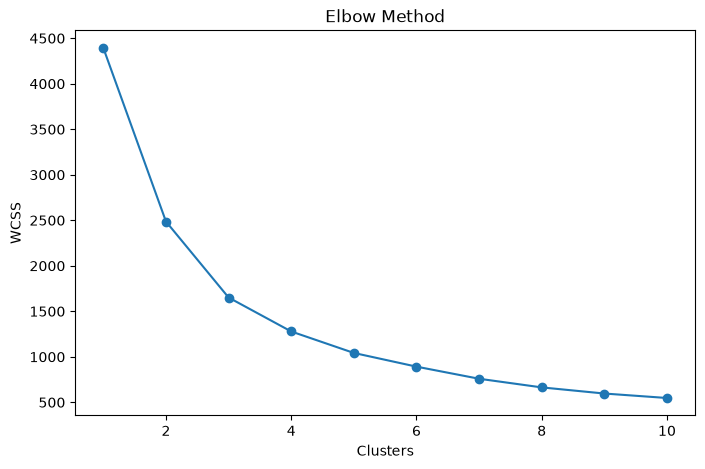

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.show()

In [18]:
scores=[]

for i in range(2,11):

    model=KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    labels=model.fit_predict(pca_data)

    score=silhouette_score(
        pca_data,
        labels
    )

    scores.append(score)

    print(
        "Clusters:",
        i,
        "Score:",
        score
    )

Clusters: 2 Score: 0.3874187315643896
Clusters: 3 Score: 0.3788230563186417
Clusters: 4 Score: 0.35197517325670385
Clusters: 5 Score: 0.3467464033711014
Clusters: 6 Score: 0.3478181389779886
Clusters: 7 Score: 0.3460854673105707
Clusters: 8 Score: 0.3460398562845369
Clusters: 9 Score: 0.343969156712573
Clusters: 10 Score: 0.3359349041814152


In [19]:
kmeans=KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters=kmeans.fit_predict(pca_data)

In [20]:
pca_df["Cluster"]=clusters

pca_df.head()

,PC1,PC2,Cluster
0,2.750031,1.189220,2
1,-1.990696,0.561052,1
2,3.028703,0.718868,2
3,-1.500285,-1.541260,0
4,2.280168,1.638204,2


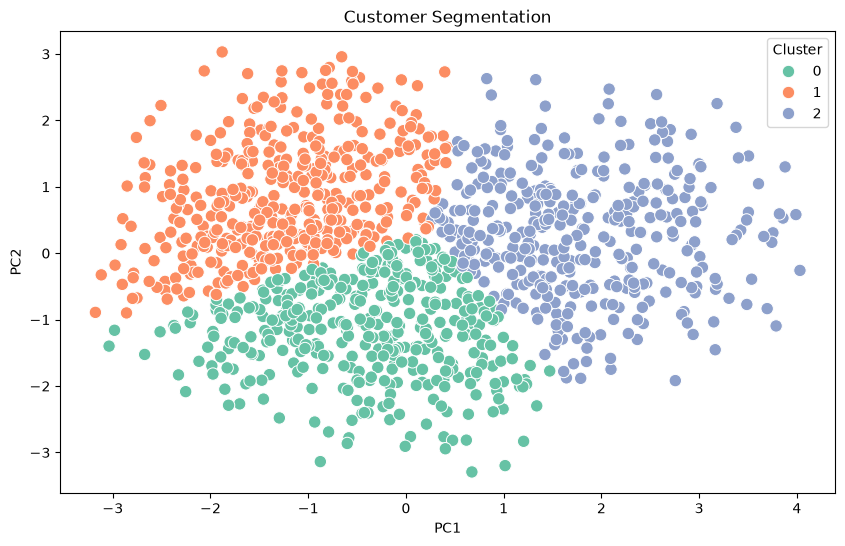

In [21]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("Customer Segmentation")

plt.show()

In [22]:
print(pca_df["Cluster"].value_counts())

Cluster
1    420
0    399
2    381
Name: count, dtype: int64


In [23]:
df["Cluster"]=clusters

In [24]:
summary=df.groupby("Cluster").agg({

    "Quantity":"mean",

    "UnitPrice":"mean",

    "ItemsInCart":"mean",

    "TotalPrice":"mean"

})

summary

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Cluster,,,,
0,3.132832,210.287970,5.879699,606.171629
1,1.690476,364.027190,3.661905,588.482738
2,4.133858,501.047192,7.081365,2036.054409


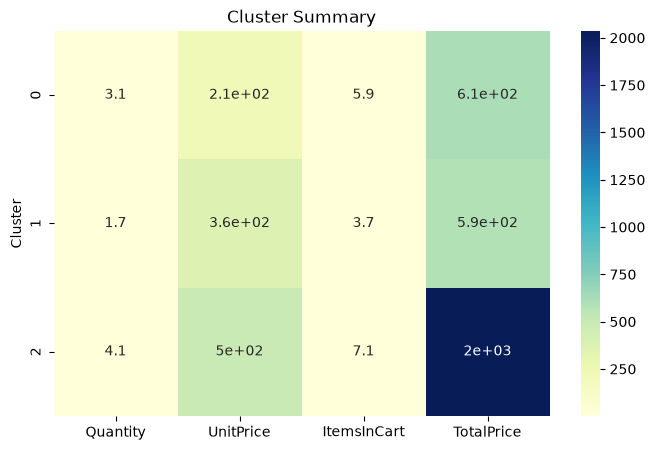

In [25]:
plt.figure(figsize=(8,5))

sns.heatmap(
    summary,
    annot=True,
    cmap="YlGnBu"
)

plt.title("Cluster Summary")

plt.show()

In [1]:
df.to_excel(
    "CustomerSegmentation_Output.xlsx",
    index=False
)

print("Project Completed Successfully")

NameError: name 'df' is not defined